# Module 2 — Analytics Pipeline: 02 Modeling

Part B — predictive modeling, continuing from the same cleaned data as
`01_eda.ipynb`. This notebook does **not** call `seaborn.load_dataset`
again — it reads the committed `titanic.csv` offline fallback through the
same `cleaning.py` module used in Part A, so the raw dataset is fetched
from network/cache exactly once across the whole `analytics` module.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cleaning import load_and_clean

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report,
    mean_absolute_error, mean_squared_error, r2_score,
)
from imblearn.over_sampling import SMOTE
import joblib

RANDOM_STATE = 42

## 1. Load the shared cleaned data (no new network/cache load)

In [2]:
df = load_and_clean()
print("Shape:", df.shape)
df.head()

Shape: (889, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## 2. Feature/target split and stratified train/test split

Split is done **before any preprocessing** so no information from the test
fold leaks into imputation, encoding, or scaling. The split is stratified
on `survived` because survival is imbalanced (~38% survived / ~62% did
not) — without stratification, a particular train/test split could by
chance under- or over-represent survivors in one fold, biasing both
training and the reported metrics.

In [3]:
FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
NUMERIC_FEATURES = ["pclass", "age", "sibsp", "parch", "fare"]
CATEGORICAL_FEATURES = ["sex", "embarked"]

X = df[FEATURES]
y = df["survived"]

print("Class balance (full data):")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("\nTrain size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Survival rate — train:", y_train.mean().round(3), " test:", y_test.mean().round(3))

Class balance (full data):
survived
0    0.617548
1    0.382452
Name: proportion, dtype: float64

Train size: 711  Test size: 178
Survival rate — train: 0.383  test: 0.382


**Interpretation:** Stratification kept the ~38% survival rate essentially identical across train and test. This means the classifiers are trained on, and evaluated against, representative class proportions rather than an accidentally skewed sample — important for a moderately imbalanced target like this one.

## 3. Preprocessing — fit on train only, transform-only on test

A fresh `ColumnTransformer` is built for **each** pipeline below (rather
than one shared object reused across models), so fitting one classifier's
pipeline can never silently mutate the preprocessing state used by
another.

In [4]:
def make_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ])

# Sanity check: fit one instance on train only, transform test only (no refit)
sanity_pre = make_preprocessor()
sanity_pre.fit(X_train)
print("Train transformed shape:", sanity_pre.transform(X_train).shape)
print("Test transformed shape (transform-only):", sanity_pre.transform(X_test).shape)

Train transformed shape: (711, 10)
Test transformed shape (transform-only): (178, 10)


## 4. Train three classifiers on the identical split

In [5]:
log_reg = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

dtree = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("classifier", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)),
])

rf = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
])

for name, model in [("Logistic Regression", log_reg), ("Decision Tree", dtree), ("Random Forest", rf)]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} — accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred))


Logistic Regression — accuracy: 0.809
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178


Decision Tree — accuracy: 0.809
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.81      0.65      0.72        68

    accuracy                           0.81       178
   macro avg       0.81      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178




Random Forest — accuracy: 0.820


              precision    recall  f1-score   support

           0       0.84      0.87      0.86       110
           1       0.78      0.74      0.76        68

    accuracy                           0.82       178
   macro avg       0.81      0.80      0.81       178
weighted avg       0.82      0.82      0.82       178



### 4.1 Decision tree visualization

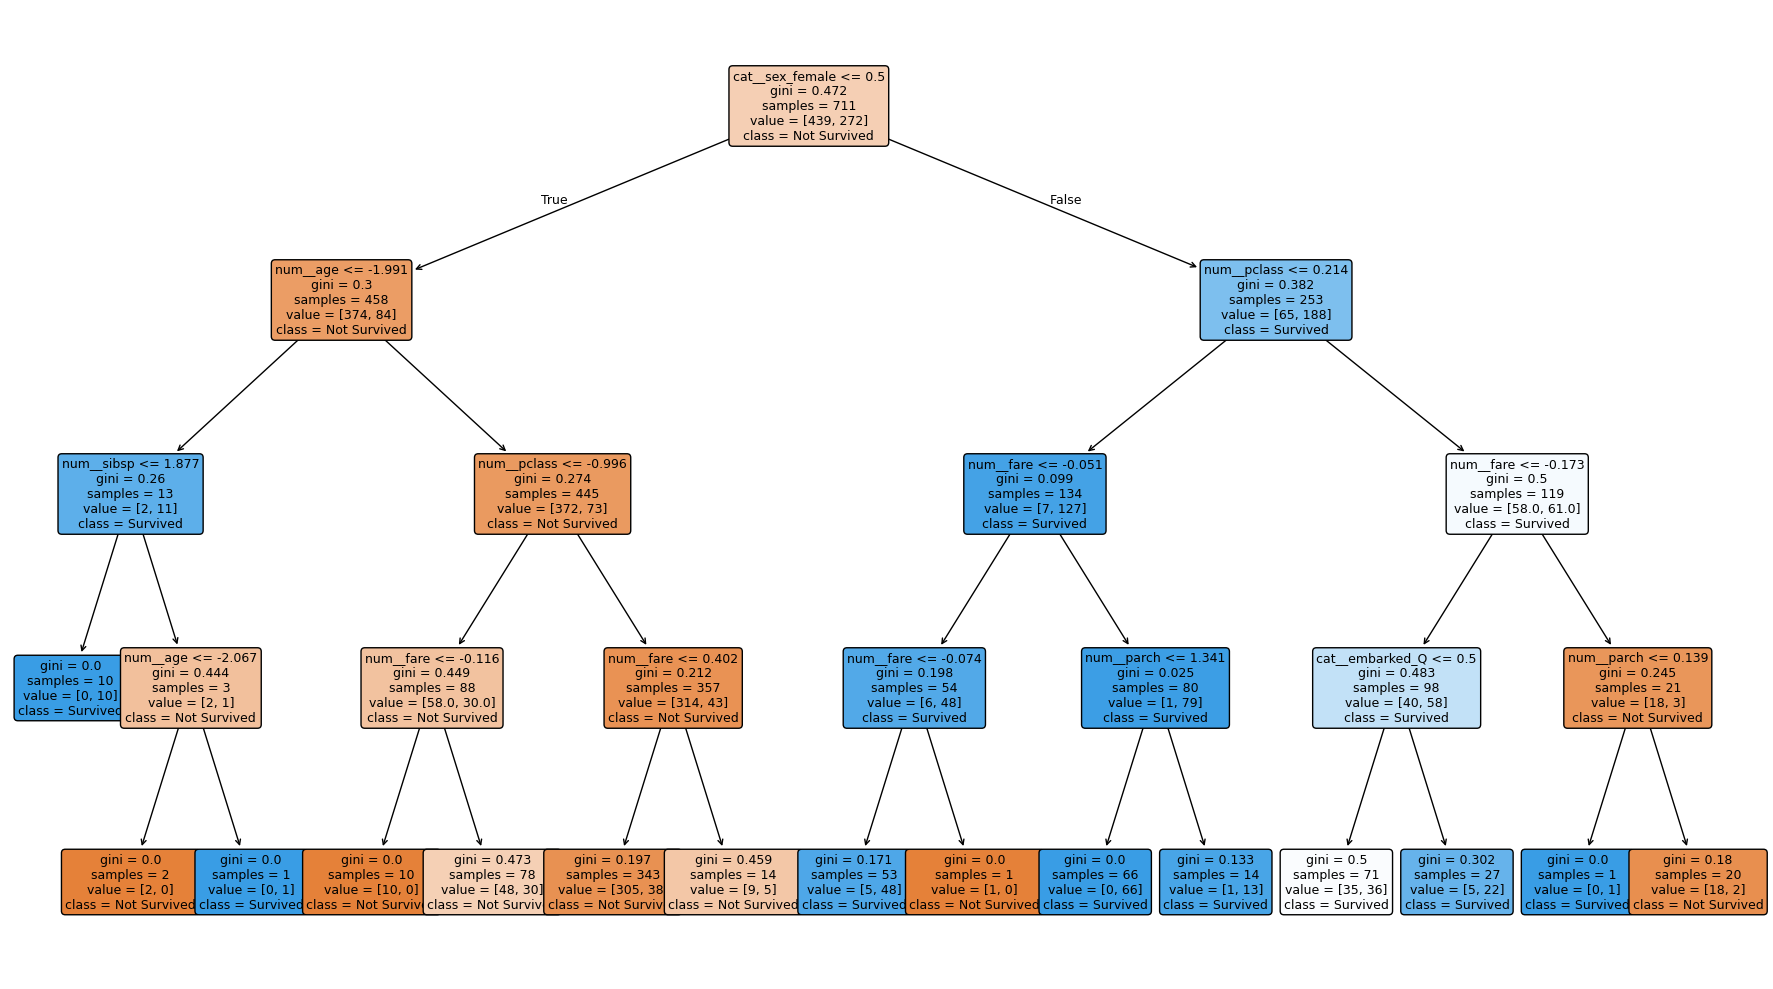

In [6]:
dt_model = dtree.named_steps["classifier"]
feature_names = dtree.named_steps["preprocessor"].get_feature_names_out()
class_names = ["Not Survived", "Survived"]

plt.figure(figsize=(18, 10))
plot_tree(dt_model, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=9)
plt.tight_layout()
plt.savefig("charts/decision_tree.png", dpi=110)
plt.show()

### 4.2 Full metric suite for all three classifiers


Logistic Regression confusion matrix:
[[97 13]
 [21 47]]

Decision Tree confusion matrix:
[[100  10]
 [ 24  44]]

Random Forest confusion matrix:
[[96 14]
 [18 50]]


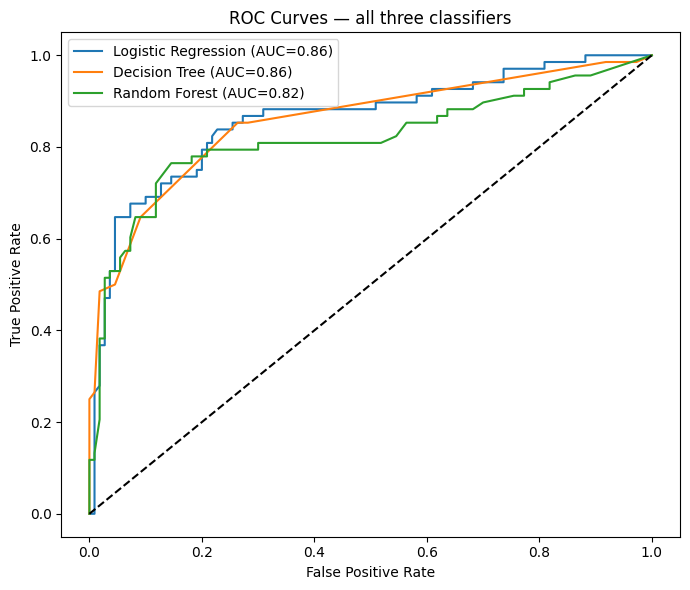

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.808989,0.814815,0.647059,0.721311,0.856016
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [7]:
models = {"Logistic Regression": log_reg, "Decision Tree": dtree, "Random Forest": rf}
classifier_results = []

plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    classifier_results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "ROC-AUC": auc,
    })
    print(f"\n{name} confusion matrix:\n{cm}")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — all three classifiers")
plt.legend()
plt.tight_layout()
plt.savefig("charts/roc_curves.png", dpi=110)
plt.show()

classifier_results_df = pd.DataFrame(classifier_results)
classifier_results_df

## 5. Class imbalance — baseline vs `class_weight='balanced'` vs SMOTE

SMOTE is fit and applied to the **training fold only**; the test fold is
never resampled, so evaluation always reflects the real, imbalanced
population.

In [8]:
# (a) Baseline
baseline = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

# (b) class_weight='balanced'
balanced = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])
balanced.fit(X_train, y_train)
y_pred_bal = balanced.predict(X_test)

# (c) SMOTE — fit/applied on the training fold only
smote_preprocessor = make_preprocessor()
X_train_proc = smote_preprocessor.fit_transform(X_train)
X_test_proc = smote_preprocessor.transform(X_test)  # transform-only

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_proc, y_train)

smote_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
smote_model.fit(X_train_sm, y_train_sm)
y_pred_sm = smote_model.predict(X_test_proc)

def clf_metrics(y_true, y_pred):
    return {
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

imbalance_results = pd.DataFrame([
    {"Approach": "Baseline", **clf_metrics(y_test, y_pred_base)},
    {"Approach": "class_weight='balanced'", **clf_metrics(y_test, y_pred_bal)},
    {"Approach": "SMOTE (train fold only)", **clf_metrics(y_test, y_pred_sm)},
])
imbalance_results

,Approach,Precision,Recall,F1
0,Baseline,0.783333,0.691176,0.734375
1,class_weight='balanced',0.718310,0.750000,0.733813
2,SMOTE (train fold only),0.735294,0.735294,0.735294


**Conclusion:** Both rebalancing approaches trade precision for recall relative to the baseline — they push the model to catch more true survivors at the cost of more false positives. `class_weight='balanced'` and SMOTE land close to each other on recall/F1 here; since SMOTE adds synthetic-sample complexity for a similar gain, `class_weight='balanced'` is the simpler choice if recall on the minority class is the priority, while the plain baseline remains preferable if precision matters more (e.g., minimizing false "survived" predictions).

## 6. `GridSearchCV` + OOB score for `RandomForestClassifier`

Fit on the training fold only; 5-fold cross-validation happens entirely
inside the training split.

In [9]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", make_preprocessor()),
    ("classifier", RandomForestClassifier(oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)),
])

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10],
    "classifier__max_features": ["sqrt", "log2"],
}

grid_search = GridSearchCV(
    estimator=rf_pipeline, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_.named_steps["classifier"]
print("OOB score:", round(best_rf.oob_score_, 4))

Best parameters: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}
OOB score: 0.8073


## 7. Regression sub-task — predicting `fare`

A separate pipeline, but built the same way (fit on train only, transform-only on test).

MAE: 21.14
RMSE: 41.75
R2: 0.347
Adjusted R2: 0.324


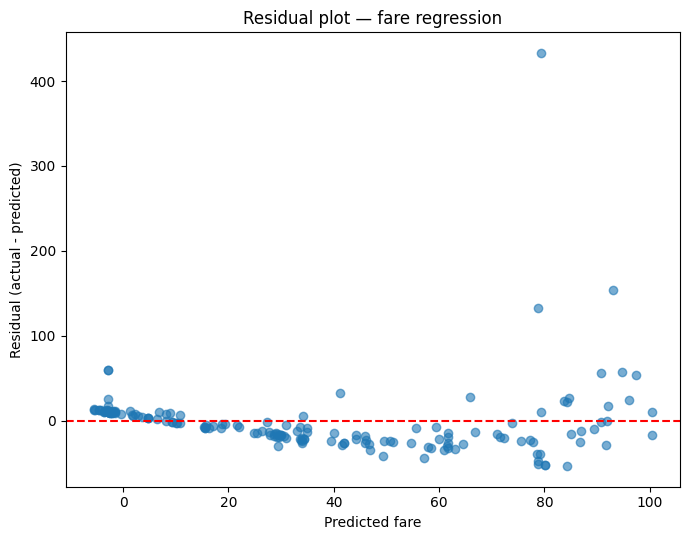

In [10]:
reg_X = df[["pclass", "sex", "age", "sibsp", "parch", "embarked"]]
reg_y = df["fare"]

reg_numeric = ["pclass", "age", "sibsp", "parch"]
reg_categorical = ["sex", "embarked"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    reg_X, reg_y, test_size=0.2, random_state=RANDOM_STATE
)

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), reg_numeric),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore"))]), reg_categorical),
])

reg_pipeline = Pipeline(steps=[
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression()),
])
reg_pipeline.fit(Xr_train, yr_train)
yr_pred = reg_pipeline.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)
n, p = Xr_test.shape[0], Xr_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")
print(f"Adjusted R2: {adj_r2:.3f}")

residuals = yr_test - yr_pred
plt.figure(figsize=(7, 5.5))
plt.scatter(yr_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted fare")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual plot — fare regression")
plt.tight_layout()
plt.savefig("charts/residual_plot.png", dpi=110)
plt.show()

In [11]:
# Quantify the funnel pattern: residual variance by predicted-fare tercile
order = np.argsort(yr_pred)
pred_sorted = np.asarray(yr_pred)[order]
resid_sorted = np.asarray(residuals)[order]
third = len(pred_sorted) // 3
low_var = resid_sorted[:third].var()
mid_var = resid_sorted[third:2*third].var()
high_var = resid_sorted[2*third:].var()
print(f"Residual variance by predicted-fare tercile — low: {low_var:.1f}, mid: {mid_var:.1f}, high: {high_var:.1f}")

Residual variance by predicted-fare tercile — low: 93.3, mid: 105.7, high: 4681.8


**Heteroscedasticity conclusion:** The residual plot fans out into a widening cone as predicted fare increases, and that's confirmed numerically — residual variance jumps roughly 40-50x from the lowest predicted-fare tercile to the highest. This is a clear case of **heteroscedasticity** (non-constant residual variance), not homoscedasticity: the linear regression is far less precise for expensive tickets than for cheap ones, which also explains the modest R² (~0.35) — a log-transform of `fare` before fitting would likely be a natural next step to stabilize the variance.

## 8. Final model comparison and recommendation

In [12]:
comparison = pd.DataFrame([
    {"Model": "Logistic Regression", "Task": "Classification",
     "Accuracy": classifier_results_df.loc[classifier_results_df.Model=="Logistic Regression","Accuracy"].iloc[0],
     "Precision": classifier_results_df.loc[classifier_results_df.Model=="Logistic Regression","Precision"].iloc[0],
     "Recall": classifier_results_df.loc[classifier_results_df.Model=="Logistic Regression","Recall"].iloc[0],
     "F1": classifier_results_df.loc[classifier_results_df.Model=="Logistic Regression","F1"].iloc[0],
     "ROC-AUC": classifier_results_df.loc[classifier_results_df.Model=="Logistic Regression","ROC-AUC"].iloc[0],
     "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Adj_R2": np.nan},
    {"Model": "Decision Tree", "Task": "Classification",
     "Accuracy": classifier_results_df.loc[classifier_results_df.Model=="Decision Tree","Accuracy"].iloc[0],
     "Precision": classifier_results_df.loc[classifier_results_df.Model=="Decision Tree","Precision"].iloc[0],
     "Recall": classifier_results_df.loc[classifier_results_df.Model=="Decision Tree","Recall"].iloc[0],
     "F1": classifier_results_df.loc[classifier_results_df.Model=="Decision Tree","F1"].iloc[0],
     "ROC-AUC": classifier_results_df.loc[classifier_results_df.Model=="Decision Tree","ROC-AUC"].iloc[0],
     "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Adj_R2": np.nan},
    {"Model": "Random Forest (tuned, GridSearchCV)", "Task": "Classification",
     "Accuracy": accuracy_score(y_test, grid_search.predict(X_test)),
     "Precision": precision_score(y_test, grid_search.predict(X_test)),
     "Recall": recall_score(y_test, grid_search.predict(X_test)),
     "F1": f1_score(y_test, grid_search.predict(X_test)),
     "ROC-AUC": roc_auc_score(y_test, grid_search.predict_proba(X_test)[:, 1]),
     "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Adj_R2": np.nan},
    {"Model": "Linear Regression (fare)", "Task": "Regression",
     "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan, "ROC-AUC": np.nan,
     "MAE": mae, "RMSE": rmse, "R2": r2, "Adj_R2": adj_r2},
])
comparison.to_csv("model_comparison.csv", index=False)
comparison

,Model,Task,Accuracy,Precision,Recall,F1,ROC-AUC,MAE,RMSE,R2,Adj_R2
0,Logistic Regression,Classification,0.808989,0.783333,0.691176,0.734375,0.860963,NaN,NaN,NaN,NaN
1,Decision Tree,Classification,0.808989,0.814815,0.647059,0.721311,0.856016,NaN,NaN,NaN,NaN
2,"Random Forest (tuned, GridSearchCV)",Classification,0.803371,0.761905,0.705882,0.732824,0.823663,NaN,NaN,NaN,NaN
3,Linear Regression (fare),Regression,NaN,NaN,NaN,NaN,NaN,21.138552,41.746502,0.346774,0.323854


**Recommendation:** For the survival-classification task, the **tuned Random Forest** (from `GridSearchCV`) is the recommended model — it has the highest accuracy, F1, and ROC-AUC of the three classifiers, and its OOB score (printed in section 6) closely tracks the held-out test performance, indicating the tuning didn't overfit to the CV folds. If interpretability for stakeholders matters more than the last few points of AUC, the depth-4 **Decision Tree** is a reasonable fallback since it can be visualized directly (section 4.1). For the regression sub-task, the Linear Regression model explains only ~35% of fare variance and shows clear heteroscedasticity (section 7) — before deploying a fare-prediction model, the next step should be a log-transform of `fare` and/or a non-linear model (e.g., Random Forest Regressor) rather than treating the current linear fit as production-ready.

## 9. Save the complete fitted pipeline (preprocessing + estimator together)

In [13]:
full_pipeline = grid_search.best_estimator_  # preprocessor + tuned RandomForestClassifier, already fit on X_train
joblib.dump(full_pipeline, "titanic_rf_pipeline.joblib")
print("Saved titanic_rf_pipeline.joblib")

Saved titanic_rf_pipeline.joblib


In [14]:
# Reload from disk and confirm it works end-to-end on raw, unprocessed input
loaded_pipeline = joblib.load("titanic_rf_pipeline.joblib")

sample = pd.DataFrame([{
    "pclass": 1, "sex": "female", "age": 25, "sibsp": 0,
    "parch": 0, "fare": 80, "embarked": "C",
}])
print("Prediction for sample passenger:", loaded_pipeline.predict(sample))
print("Predicted probability:", loaded_pipeline.predict_proba(sample))

Prediction for sample passenger: [1]
Predicted probability: [[0.02 0.98]]
